# mmBERT-small baseline

This notebook fine-tunes [`jhu-clsp/mmBERT-small`](https://huggingface.co/jhu-clsp/mmBERT-small) for three-class German text classification.

The model distinguishes between:

- **Human-written text**
- **AI-generated text**
- **AI-assisted text**

Training uses the prepared Hugging Face dataset created for this project, with document-level train, validation, and test splits to reduce source leakage.

The notebook follows a complete experimental pipeline: dataset loading, tokenization, model fine-tuning, validation, probability calibration, test-set evaluation, confusion-matrix analysis, length-bias analysis, learning-curve experiments, and model export.

The notebook is designed to run with GPU acceleration. Required Python packages are installed in the setup cells when running in Google Colab.

## Imports

Load the core libraries used throughout the notebook for numerical processing,
dataset handling, transformer fine-tuning, and model evaluation.

In [77]:
import numpy as np
import pandas as pd
import torch
import transformers
from pathlib import Path
from importlib.metadata import version
import json
import platform
import gc
import time
from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()
from datasets import load_from_disk
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,

)

### Configuration and dataset loading

Define the main experiment settings and load the prepared three-class Hugging Face dataset from disk.

In [61]:
MODEL_NAME = "jhu-clsp/mmBERT-small"
DATASET_PATH = "hf-dataset-3class-full"

MAX_LENGTH = 512
RANDOM_STATE = 17

dataset = load_from_disk(
    DATASET_PATH
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

### Tokenization

Load the mmBERT tokenizer, tokenize all dataset splits with a maximum sequence
length of 512 tokens, and prepare dynamic padding for efficient batching.

In [62]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

columns_to_remove = [
    column
    for column in dataset["train"].column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing dataset",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

### Model initialization

Load the pretrained mmBERT-small checkpoint with a three-class classification
head and determine the mixed-precision format supported by the available GPU.

In [78]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "HUMAN",
        1: "AI",
        2: "AI_ASSISTED",
    },
    label2id={
        "HUMAN": 0,
        "AI": 1,
        "AI_ASSISTED": 2,
    },
)

use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

print("BF16:", use_bf16)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

BF16: True


### Training configuration

Define the optimization settings, evaluation strategy, mixed-precision behavior,
and accuracy metric used during fine-tuning.

In [66]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }


training_args = TrainingArguments(
    output_dir="checkpoints-mmbert-small",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=235,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,

    report_to="none",

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

### Trainer

Create the Hugging Face Trainer using the tokenized training and validation sets,
dynamic padding, accuracy evaluation, and early stopping.

In [67]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

In [68]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.228636,0.322153,0.924639
2,0.167976,0.261356,0.951136
3,0.056645,0.394205,0.956297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Probability calibration

Use the validation split to learn a temperature-scaling parameter for mmBERT.
Temperature scaling adjusts the confidence of the model's predicted probabilities
without changing the predicted class labels.

In [69]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = np.asarray(
    validation_output.predictions
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)


def fit_temperature(logits, labels):

    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float64,
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long,
    )

    log_temperature = torch.nn.Parameter(
        torch.zeros(
            (),
            dtype=torch.float64,
        )
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()

        temperature = log_temperature.exp()

        loss = criterion(
            logits_tensor / temperature,
            labels_tensor,
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    return float(
        log_temperature.exp().detach()
    )


def probabilities_from_logits(
    logits,
    temperature=1.0,
):

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / temperature
    )

    scaled_logits -= scaled_logits.max(
        axis=1,
        keepdims=True,
    )

    exponentiated = np.exp(
        scaled_logits
    )

    return (
        exponentiated
        / exponentiated.sum(
            axis=1,
            keepdims=True,
        )
    )


MMBERT_TEMPERATURE = fit_temperature(
    validation_logits,
    y_validation,
)

print(
    f"Learned mmBERT temperature: "
    f"{MMBERT_TEMPERATURE:.4f}"
)

Learned mmBERT temperature: 3.9188


### Calibration evaluation

Compare the model's probability quality before and after temperature scaling.
The Brier score and log loss measure how well the predicted probabilities match
the true class labels, with lower values indicating better calibration.

In [70]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):

    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


uncalibrated_validation_probabilities = probabilities_from_logits(
    validation_logits
)

calibrated_validation_probabilities = probabilities_from_logits(
    validation_logits,
    MMBERT_TEMPERATURE,
)


calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",

            "Brier score": multiclass_brier_score(
                y_validation,
                uncalibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                uncalibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },

        {
            "model": "Temperature-scaled",

            "Brier score": multiclass_brier_score(
                y_validation,
                calibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                calibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },
    ]
).set_index("model")


calibration_comparison.style.format(
    "{:.4f}"
)

,Brier score,Log loss
model,,
Uncalibrated,0.0825,0.3858
Temperature-scaled,0.0714,0.1464


### Final split evaluation

Evaluate the calibrated model on the training, validation, and test splits using
accuracy, multiclass Brier score, log loss, and confusion matrices.

In [71]:
split_logits = {
    "validation": validation_logits
}

for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )

    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def evaluate_split(split_name):
    y_true = np.asarray(
        dataset[split_name]["label"],
        dtype=np.int64,
    )

    probabilities = probabilities_from_logits(
        split_logits[split_name],
        MMBERT_TEMPERATURE,
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),

        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),

        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,99.83%,0.0060,0.0336,[[8333 0 9] [ 0 8322 2] [ 29 3 8288]]
validation,95.63%,0.0714,0.1464,[[911 0 60] [ 4 957 6] [ 44 13 911]]
test,95.98%,0.0689,0.1397,[[864 2 48] [ 0 906 6] [ 44 10 857]]


### Test-set confusion matrix

Visualize the three-class confusion matrix on the test split to inspect which
classes are predicted correctly and where misclassifications occur.

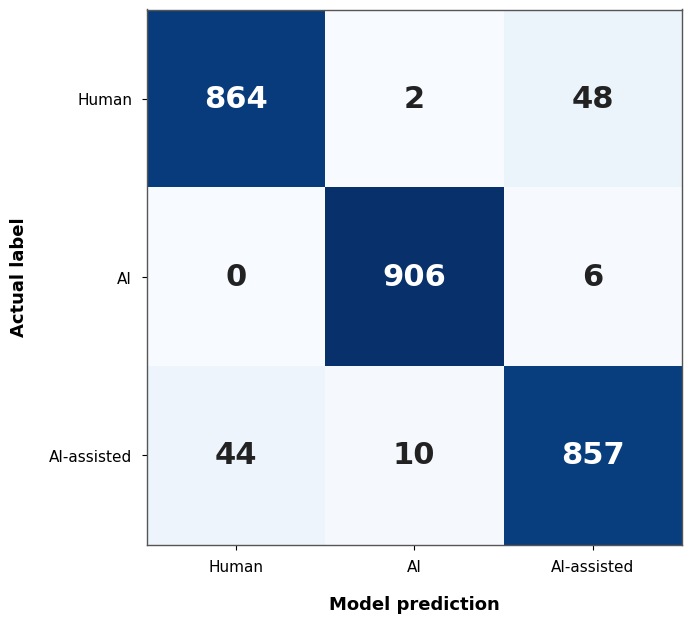

In [72]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-confmat-3class.svg"
)

plt.show()

### Binary Human-vs-AI confusion matrix

Evaluate the model only on Human and fully AI-generated test samples. AI-assisted
samples are excluded, and the remaining Human and AI probabilities are
renormalized before applying a binary decision threshold.

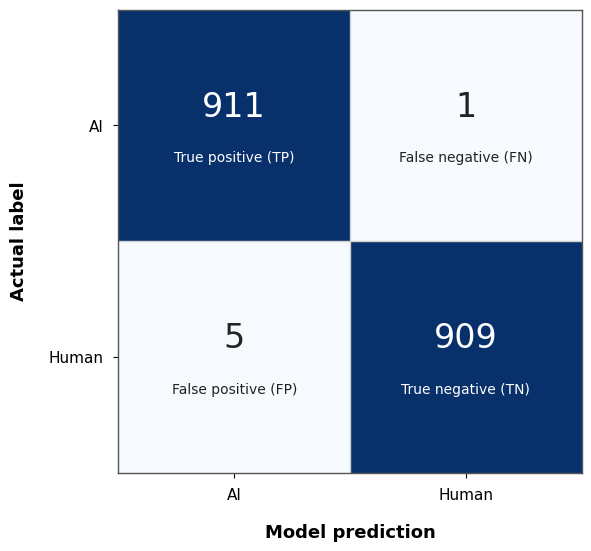

In [73]:
y_test_all = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = y_test_all != 2

y_test = y_test_all[mask]

test_logits_binary = split_logits["test"][mask]

test_probabilities = probabilities_from_logits(
    test_logits_binary,
    MMBERT_TEMPERATURE,
)

human_prob = test_probabilities[:, 0]
ai_prob = test_probabilities[:, 1]

total = human_prob + ai_prob

human_prob = human_prob / total
ai_prob = ai_prob / total

y_test_pred = (
    ai_prob >= 0.5
).astype(np.int64)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[1, 0],
)

cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(2):
    for column in range(2):

        value = test_matrix[
            row,
            column
        ]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_yticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.axhline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.axvline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-confmat-human-ai.svg"
)

plt.show()

### Error analysis

Inspect the highest-confidence misclassifications on the test set, including the
true label, predicted class, calibrated class probabilities, source information,
generator metadata, and a short text preview.

In [74]:
label_names = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

prediction_confidence = np.max(
    test_probabilities,
    axis=1,
)

test_errors = pd.DataFrame(
    {
        "id": dataset["test"]["id"],
        "actual": [
            label_names[label]
            for label in y_test
        ],
        "prediction": [
            label_names[label]
            for label in y_test_pred
        ],
        "prediction_confidence": prediction_confidence,
        "human_probability": test_probabilities[:, 0],
        "ai_probability": test_probabilities[:, 1],
        "ai_assisted_probability": test_probabilities[:, 2],
        "source_name": dataset["test"]["source_name"],
        "generator_model": dataset["test"]["generator_model"],
        "text": [
            text[:300]
            for text in dataset["test"]["text"]
        ],
    }
)

test_errors = test_errors[
    test_errors["actual"]
    != test_errors["prediction"]
].copy()

test_errors.sort_values(
    "prediction_confidence",
    ascending=False,
).head(20).style.format(
    {
        "prediction_confidence": "{:.2%}",
        "human_probability": "{:.2%}",
        "ai_probability": "{:.2%}",
        "ai_assisted_probability": "{:.2%}",
    }
)

,id,actual,prediction,prediction_confidence,human_probability,ai_probability,ai_assisted_probability,source_name,generator_model,text
2682,30070,AI-assisted,AI,99.89%,0.00%,99.89%,0.11%,SSOAR,gpt-6-luna,"Nach dem geltenden Abstimmungsmodus verfügen die großen Staaten über 29 Stimmen, die kleinsten hingegen nur über drei. Gemessen an ihrer Bevölkerungszahl stünden Deutschland jedoch 767, Frankreich 554 und Großbritannien 552 Stimmen zu. Diese machtpolitische Schieflage verschärft die Akzeptanz- und L"
1645,18518,AI,AI-assisted,99.78%,0.06%,0.16%,99.78%,SSOAR,gpt-6-luna,"An der FernUniversität in Hagen widmet sich das Lehrgebiet Multimedia und Internetanwendungen seit Langem der dauerhaften Sicherung digitaler Daten. Ein Schwerpunkt liegt darauf, Daten mit ergänzenden Informationen auszustatten, damit sie auch künftig sinnvoll weiterverwendet werden können. Darüber"
1224,13840,AI,AI-assisted,99.70%,0.04%,0.26%,99.70%,SSOAR,gemini,Im Feld internationaler Konfliktbearbeitung nehmen die Vereinten Nationen weiterhin eine herausragende Vermittlungsrolle ein: Keine andere internationale Organisation tritt so häufig als Mediatorin in zwischenstaatlichen und innerstaatlichen Konflikten auf (Bercovitch & Schneider 2000: 156; Greig &
2083,23447,AI-assisted,AI,99.70%,0.00%,99.70%,0.30%,SSOAR,gemini,"Bei den Jugendlichen türkischer Herkunft fällt der Zusammenhang zwischen den beiden Messzeitpunkten mit R = 0,37 schwächer aus. Dessen ungeachtet erweist sich der Erziehungsstil im Mittel als stabil (t = 0,69; n.s.). Im direkten Vergleich zwischen deutschen und türkischen Heranwachsenden zeigt sich"
2659,29837,AI-assisted,AI,99.35%,0.02%,99.35%,0.63%,SSOAR,gpt-6-luna,"Der Datensatz enthält für jede befragte Person und jeden Befragungstag jeweils 144 Aktivitäten, die in Zehn-Minuten-Intervallen erfasst wurden. Die Auswertung dieser Studie konzentriert sich auf die 144 Hauptaktivitäten des Tages. Bei der ZVE handelt es sich um eine wiederholte Querschnittsbefragung"
602,6851,Human,AI-assisted,99.31%,0.45%,0.24%,99.31%,peDOCS (DIPF),None,Eine kritische Reflexion der eigenen gesellschaftlichen Position in der Gestaltung der Bildungs- und Beratungspraxis sowie das Nachdenken über Fragen von Repräsentation sind daher unerlässlich. Bildungsräume sind Teil gesellschaftlicher Bedingungen und bedürfen daher einer Auseinandersetzung mit den
1855,20857,AI-assisted,AI,98.93%,0.03%,98.93%,1.03%,peDOCS (DIPF),gpt-5.6-luna,"Die Verteilungen der meisten imputierten Variablen stimmen weitgehend mit den beobachteten Werten überein. Eine Ausnahme bildet die Verteilung des Kriteriums: In den vollständigen Datensätzen beträgt die Studienabbruchquote 25,6 Prozent und liegt damit in einer ähnlichen Größenordnung wie die in and"
465,5057,Human,AI-assisted,98.88%,1.08%,0.04%,98.88%,Refubium (FU Berlin),None,"In seiner Begriffsgeschichte des Wortes „Ghetto“ spannt Jürgen Heyde einen großen historischen Bogen von den namensgebenden jüdischen Vierteln in italienischen Städten im 16. Jahrhundert über die in (Ost-)Mitteleuropa geführten innerjüdischen Emanzipationsdiskurse, die sich um den Begriff des Ghetto"
460,5040,Human,AI-assisted,98.59%,1.21%,0.21%,98.59%,Refubium (FU Berlin),None,"Der selektive Effekt des Kapillarendothels beruht jedoch überwiegend auf der negativen Ladung, die durch das Überspannen einer Glykokalyx zustande kommt (Jeansson, 2006). Das Filtrat erreicht im weiteren Verlauf die glomeruläre Basalmembran, die sich aus der Basalmembran der Endothelzellen und jener"
153,1808,Human,AI-assisted,98.18%,1.54%,0.28%,98.18%,SSOAR,None,"Aus völkerrechtlicher Perspektive erscheint die Antwort zunächst recht einfach. Mit Ausnahme von international anerkannten Flüchtlingen genießen souveräne Staaten absolute Hoheit über ihre Grenzen und damit das Recht, nach eigenem Ermessen über die Aufnahme oder Ablehnung von Migrant*innen zu entsch"


### Model export

Save the fine-tuned model and tokenizer together with the calibration parameter,
label mapping, validation performance, training configuration, and software
versions required to reproduce inference.

In [75]:
ARTIFACT_DIR = Path("artifacts") / "mmbert-small-3class"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

trainer.save_model(
    ARTIFACT_DIR
)

tokenizer.save_pretrained(
    ARTIFACT_DIR
)

validation_predictions = np.argmax(
    validation_logits,
    axis=1,
)

best_validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

metadata = {
    "dataset": DATASET_PATH,
    "base_model": MODEL_NAME,
    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },
    "max_length": MAX_LENGTH,
    "calibration": "temperature scaling",
    "temperature": float(
        MMBERT_TEMPERATURE
    ),
    "best_validation_accuracy": float(
        best_validation_accuracy
    ),
    "best_checkpoint": (
        trainer.state.best_model_checkpoint
    ),
    "random_state": RANDOM_STATE,
    "python_version": platform.python_version(),
    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print(
    f"Saved model and tokenizer to: "
    f"{ARTIFACT_DIR}"
)

print(
    f"Saved detector configuration to: "
    f"{METADATA_PATH}"
)

print(
    f"Validation accuracy: "
    f"{best_validation_accuracy:.2%}"
)

print(
    f"Temperature: "
    f"{MMBERT_TEMPERATURE:.4f}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: artifacts/mmbert-small-3class
Saved detector configuration to: artifacts/mmbert-small-3class/detector-config.json
Validation accuracy: 95.63%
Temperature: 3.9188


### Reload and test the exported model

Reload the saved model, tokenizer, and detector configuration from the artifact
directory, move the model to the available inference device, and run a sample
prediction using the stored temperature-scaling parameter.

In [76]:
ARTIFACT_DIR = Path("artifacts") / "mmbert-small-3class"

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    ARTIFACT_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)

loaded_config = json.loads(
    METADATA_PATH.read_text(
        encoding="utf-8"
    )
)

if torch.cuda.is_available():
    inference_device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    inference_device = torch.device("mps")

else:
    inference_device = torch.device("cpu")

print("Device:", inference_device)

loaded_model.to(
    inference_device
)

loaded_model.eval()


def predict_probabilities(texts):
    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    )

    inputs = {
        key: value.to(inference_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        logits = loaded_model(
            **inputs
        ).logits

        calibrated_logits = (
            logits
            / loaded_config["temperature"]
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

    return probabilities.cpu().numpy()


id2label = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

texts = [
    """
    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung zu messen, anstatt politische Ermessensspielräume an automatisierte Prozesse abzutreten.
    """
]

probabilities = predict_probabilities(
    texts
)

for text, probs in zip(
    texts,
    probabilities,
):
    prediction = int(
        np.argmax(probs)
    )

    label = id2label[
        prediction
    ]

    print(
        f"Prediction: {label}"
    )

    print(
        f"Human:       {probs[0]:.1%}"
    )

    print(
        f"AI:          {probs[1]:.1%}"
    )

    print(
        f"AI-assisted: {probs[2]:.1%}"
    )

    print(
        f"\n{text}"
    )

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Device: cuda
Prediction: AI
Human:       0.0%
AI:          100.0%
AI-assisted: 0.0%


    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung

### Length-bias analysis

Evaluate model performance across different text-length ranges to check whether
classification quality changes for shorter or longer samples. For each length
bin, report class counts, accuracy, mean class confidence, and class-specific
error rates.

In [36]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)

test_logits = split_logits["test"]

test_probabilities = probabilities_from_logits(
    test_logits,
    MMBERT_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

word_lengths = np.asarray([
    len(text.split())
    for text in texts
])

length_bins = [
    (0, 70, "≤70"),
    (71, 150, "71–150"),
    (151, 300, "151–300"),
    (301, 500, "301–500"),
    (501, 750, "501–750"),
    (751, np.inf, "750+"),
]

rows = []

for lower, upper, name in length_bins:
    bin_mask = (
        (word_lengths >= lower)
        & (word_lengths <= upper)
    )

    y_bin = y_test[bin_mask]
    pred_bin = y_test_pred[bin_mask]
    probabilities_bin = test_probabilities[
        bin_mask
    ]

    if len(y_bin) == 0:
        continue

    human_mask = y_bin == 0
    ai_mask = y_bin == 1
    ai_assisted_mask = y_bin == 2

    mean_human_score = (
        probabilities_bin[
            human_mask,
            0
        ].mean() * 100
    )

    mean_ai_score = (
        probabilities_bin[
            ai_mask,
            1
        ].mean() * 100
    )

    mean_ai_assisted_score = (
        probabilities_bin[
            ai_assisted_mask,
            2
        ].mean() * 100
    )

    human_error_rate = np.mean(
        pred_bin[human_mask] != 0
    )

    ai_error_rate = np.mean(
        pred_bin[ai_mask] != 1
    )

    ai_assisted_error_rate = np.mean(
        pred_bin[ai_assisted_mask] != 2
    )

    rows.append(
        {
            "model": "mmBERT-small",
            "length_bin": name,
            "samples": len(y_bin),
            "human_samples": human_mask.sum(),
            "ai_samples": ai_mask.sum(),
            "ai_assisted_samples": ai_assisted_mask.sum(),
            "accuracy": accuracy_score(
                y_bin,
                pred_bin,
            ),
            "mean_human_score": mean_human_score,
            "mean_ai_score": mean_ai_score,
            "mean_ai_assisted_score": mean_ai_assisted_score,
            "human_error_rate": human_error_rate,
            "ai_error_rate": ai_error_rate,
            "ai_assisted_error_rate": ai_assisted_error_rate,
        }
    )

mmbert_length_results_3class = pd.DataFrame(
    rows
)

mmbert_length_results_3class

,model,length_bin,samples,human_samples,ai_samples,ai_assisted_samples,accuracy,mean_human_score,mean_ai_score,mean_ai_assisted_score,human_error_rate,ai_error_rate,ai_assisted_error_rate
0,mmBERT-small,≤70,399,134,134,131,0.852130,83.495419,93.063056,69.428769,0.104478,0.067164,0.274809
1,mmBERT-small,71–150,293,94,122,77,0.948805,88.169311,98.937688,88.167657,0.074468,0.008197,0.090909
2,mmBERT-small,151–300,640,207,245,188,0.965625,90.465013,99.087286,92.653429,0.053140,0.008163,0.047872
3,mmBERT-small,301–500,342,106,89,147,0.985380,93.878404,99.873852,96.638544,0.018868,0.000000,0.020408
4,mmBERT-small,501–750,653,233,191,229,0.983155,94.904603,99.387847,95.233907,0.012876,0.005236,0.030568
5,mmBERT-small,750+,410,140,131,139,0.982927,92.760124,99.913957,96.806044,0.028571,0.000000,0.021583


### Learning-curve analysis

Train fresh mmBERT-small models on increasing fractions of the training data and
measure training accuracy, validation accuracy, generalization gap, and training
runtime. Each fraction starts from the same pretrained checkpoint to make the
comparison consistent.

In [80]:
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()

TRAINING_FRACTIONS = [
    0.01,
    0.12,
    0.25,
    0.5,
    0.1,
]

train_labels = np.asarray(
    dataset["train"]["label"],
    dtype=np.int64,
)

all_indices = np.arange(
    len(dataset["train"])
)

learning_curve_rows = []

for fraction in TRAINING_FRACTIONS:
    if fraction < 1.0:
        subset_indices, _ = train_test_split(
            all_indices,
            train_size=fraction,
            stratify=train_labels,
            random_state=RANDOM_STATE,
        )

    else:
        subset_indices = all_indices

    train_subset = tokenized_dataset["train"].select(
        subset_indices.tolist()
    )

    model_fraction = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label={
            0: "HUMAN",
            1: "AI",
            2: "AI_ASSISTED",
        },
        label2id={
            "HUMAN": 0,
            "AI": 1,
            "AI_ASSISTED": 2,
        },
    )

    fraction_args = TrainingArguments(
        output_dir=(
            f"learning-curve-mmbert/"
            f"{fraction}"
        ),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="no",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        save_total_limit=1,
        bf16=use_bf16,
        fp16=(
            torch.cuda.is_available()
            and not use_bf16
        ),
        report_to="none",
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )

    fraction_trainer = Trainer(
        model=model_fraction,
        args=fraction_args,
        train_dataset=train_subset,
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=1
            )
        ],
    )

    start_time = time.perf_counter()

    fraction_trainer.train()

    runtime = (
        time.perf_counter()
        - start_time
    )

    train_output = fraction_trainer.predict(
        train_subset
    )

    train_predictions = np.argmax(
        train_output.predictions,
        axis=1,
    )

    training_accuracy = accuracy_score(
        train_output.label_ids,
        train_predictions,
    )

    validation_output = fraction_trainer.predict(
        tokenized_dataset["validation"]
    )

    validation_predictions = np.argmax(
        validation_output.predictions,
        axis=1,
    )

    validation_accuracy = accuracy_score(
        validation_output.label_ids,
        validation_predictions,
    )

    learning_curve_rows.append(
        {
            "training_samples": len(train_subset),
            "training_fraction": fraction,
            "training_accuracy": training_accuracy,
            "validation_accuracy": validation_accuracy,
            "generalization_gap":
                training_accuracy - validation_accuracy,
            "training_runtime_seconds": runtime,
        }
    )

    del fraction_trainer
    del model_fraction

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

mmbert_learning_curve = pd.DataFrame(
    learning_curve_rows
)

mmbert_learning_curve

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'eval_loss': '0.7644', 'eval_accuracy': '0.6266', 'eval_runtime': '7.211', 'eval_samples_per_second': '403', 'eval_steps_per_second': '25.24', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.5801', 'eval_accuracy': '0.7106', 'eval_runtime': '7.318', 'eval_samples_per_second': '397.1', 'eval_steps_per_second': '24.87', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.5864', 'eval_accuracy': '0.924', 'eval_runtime': '7.2', 'eval_samples_per_second': '403.6', 'eval_steps_per_second': '25.28', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '111.7', 'train_samples_per_second': '67.11', 'train_steps_per_second': '8.41', 'train_loss': '0.2663', 'epoch': '3'}


,training_samples,training_fraction,training_accuracy,validation_accuracy,generalization_gap,training_runtime_seconds
0,249,0.01,0.943775,0.736752,0.207024,39.505745
1,2998,0.12,0.998332,0.930489,0.067844,129.044608
2,6246,0.25,0.998719,0.938403,0.060316,233.525313
3,12493,0.50,0.992876,0.953200,0.039676,414.461770
4,2498,0.10,0.998799,0.923950,0.074849,112.139895
